In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
import os
from sklearn.metrics import accuracy_score
import torchvision
import zipfile
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Libraries

## Utilities

In [2]:
def stable_softmax(logits):
    # Numerically stable softmax
    predictions = torch.exp(logits - torch.max(logits, dim=-1, keepdims=True).values)
    predictions = predictions / torch.sum(predictions, dim=-1, keepdims=True)
    return predictions

def predict_labels(model, dl, device="cpu"):
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            logits = model(imgs)
            predictions = logits.argmax(dim=1)
            y_pred.append(predictions.cpu())
            y_true.append(lbls.cpu())
    
    return torch.cat(y_true), torch.cat(y_pred)

def predict_proba(model, ds, device="cpu", use_stable_softmax=False, return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    probs = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            if use_stable_softmax:
                p = stable_softmax(logits)
                probs.extend(p)
            else:
                probs.extend(F.softmax(logits, dim=1))

            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(probs), torch.stack(labels)
    else:
        return torch.stack(probs)

def compute_logits(model, ds, device="cpu", return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    logits = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits.extend(model(imgs))
            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(logits), torch.stack(labels)
    else:
        return torch.stack(logits)

def predict_phi_scores(model, ds, device="cpu", return_labels=False):
    probs, labels = predict_proba(model, ds, device=device, use_stable_softmax=True, return_labels=True)
    probs, labels = probs.cpu().numpy(), labels.cpu().numpy()
    
    # Compute probability of the true class and the probability of all other classes
    # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
    p_true = probs[np.arange(probs.shape[0]), labels]
    probs[np.arange(probs.shape[0]), labels] = 0
    p_wrong = np.sum(probs, axis=-1)

    # Compute phi
    eps = 1e-45
    phis = np.log(p_true + eps) - np.log(p_wrong + eps)
    
    if return_labels:
        return phis, labels
    else:
        return phis

def predict_losses(model, ds, device="cpu", return_labels=False):
    logits, labels = compute_logits(model, ds, device=device, return_labels=True)  
    losses = F.cross_entropy(logits, labels, reduction="none")

    losses, labels = losses.cpu().numpy(), labels.cpu().numpy()

    if return_labels:
        return losses, labels
    else:
        return losses



def get_labels(ds):
    dl = DataLoader(ds, batch_size=1024)
    labels = []
    for _, lbls in dl:
        labels.extend(lbls)
    
    return torch.tensor(labels)


def compute_accuracy(model, dl, device="cpu"):
    y_true, y_pred = predict_labels(model, dl, device=device)
    return accuracy_score(y_true=y_true, y_pred=y_pred)

def compute_error_rate(model, dl, device="cpu"):
    return 1 - compute_accuracy(model, dl, device=device)


def save_model(model, name, verbose=True, device="cuda"):
    if device=="cuda":
        torch.save(model.state_dict(), f"{name}.pth")
        if verbose:
            print(f"Model params saved in '{name}.pth'")
    
    model = model.to("cpu")
    torch.save(model.state_dict(), f"{name}_cpu.pth")
    if verbose:
        print(f"Model params saved in '{name}_cpu.pth'")
    
    model.to(device)

def load_model(model, name, verbose=True, device="cuda"):
    if device=="cpu":
        path = f"{name}_cpu.pth"
    else:
        path = f"{name}.pth"
    model.load_state_dict(torch.load(path))
    if verbose:
        print(f"Model loaded from '{path}'")

def save_array(arr, name, verbose=True):
    np.save(f"{name}.npy", arr)
    if verbose:
        print(f"Array saved in '{name}.npy'")

def load_array(name, verbose=True):
    arr = np.load(f"{name}.npy")
    if verbose:
        print(f"Array loaded from '{name}.npy'")
    return arr



def roc_chart(true_memberships, scores, axis: plt.Axes, color="darkorange", title="", log_scale=False):

    fpr, tpr, roc = roc_curve(true_memberships, scores)

    axis.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
    axis.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    if log_scale:
        axis.set_xlim([1e-5, 1.0])
        axis.set_ylim([1e-5, 1.0])
        axis.set_xscale("log")
        axis.set_yscale("log")
    else:
        axis.set_xlim([0, 1.0])
        axis.set_ylim([0, 1.0])
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    if title!= "":
        axis.set_title(title)
    else:
        axis.set_title('ROC')
    axis.legend(loc="lower right")



def get_activation(name, dict):
    def hook(model, input, output):
        dict[name] = output.detach()
    return hook

def get_activations(model, img):
    handles = []
    activations = {}

    for name, layer in model.named_modules():
        if name != "":
            handles.append(layer.register_forward_hook(get_activation(name, activations)))
    
    model(img)

    for handle in handles:
        handle.remove() 

    return activations


def get_distance_between_models(model1, model2):
    with torch.no_grad():
        model1_flattened = nn.utils.parameters_to_vector(model1.parameters())
        model2_flattened = nn.utils.parameters_to_vector(model2.parameters())
        distance = torch.square(torch.norm(model1_flattened - model2_flattened))
    return distance



## FedAvg


In [3]:
import copy
from torch.utils.data import ConcatDataset, DataLoader
from typing import Any

###################
# CLASSES
###################

class Client:
    def __init__(self, id, ds, model, dl = None, data_idxs = None):
        self.id = id
        self.ds = ds
        self.dl = dl
        self.data_idxs = data_idxs
        self.model = model

class RoundLog:
    def __init__(self, round_, global_model, client_updates: dict[int, Any]):
        self.round = round_
        self.global_model = global_model
        self.client_updates = client_updates
    
    def get_partecipating_client_ids(self):
        return self.client_updates.keys()


###################
# FEDAVG
###################

def fedavg_from_state_dict(global_model, client_dicts, client_weights):
    global_model = copy.deepcopy(global_model)

    avg = {}
    total_weights = sum(client_weights)
    for key in client_dicts[0].keys():
        avg[key] = sum([client_weights[i]*cd[key] for i, cd in enumerate(client_dicts)]) / total_weights

    global_model.load_state_dict(avg)
    return global_model

def fedavg_with_weights(clients, client_weights):
    client_dicts = [c.model.state_dict() for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg_from_models(client_models, client_weights):
    client_dicts = [model.state_dict() for model in client_models]
    return fedavg_from_state_dict(client_models[0], client_dicts, client_weights)

def fedavg_data_based_weights(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [len(c.ds) for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [1 for _ in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def train_client(train_fn, global_model, client, epochs, device="cpu", inplace=False):
    client_model = copy.deepcopy(global_model)

    train_fn(client_model, client.dl, epochs, device=device)

    if inplace:
        client.model = client_model

    return client_model

def train_fedavg(init_global_model, clients, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):

    global_model = init_global_model
    if verbose:
        train_ds = ConcatDataset([c.ds for c in clients])
        train_dl = DataLoader(train_ds, batch_size=256)

    if return_log:
        logs = []
        global_model = global_model.cpu()
        logs.append(RoundLog(0, copy.deepcopy(global_model), {}))
        global_model = global_model.to(device)
    
    for r in range(1, rounds+1):
        client_updates = {}
        for client in clients:
            client_model = train_client(train_fn, global_model, client, epochs, device=device, inplace=False)
            if return_log:
                client_model = client_model.cpu()
                client_updates[client.id] = copy.deepcopy(client_model)
                client_model = client_model.to(device)
            client.model = client_model

        global_model = fedavg(clients)
        if return_log:
            global_model = global_model.cpu()
            logs.append(RoundLog(1, copy.deepcopy(global_model), client_updates))
            global_model = global_model.to(device)

        if verbose:
            #global_model = global_model.to(device)
            train_acc = compute_accuracy(global_model, train_dl, device=device)

            eval_acc = -1
            if eval_dl != None:
                eval_acc = compute_accuracy(global_model, eval_dl, device=device)
            
            print(f"Ended training for round {r}/{rounds}, train acc = {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    if return_log:
        return global_model, logs
    else:
        return global_model


def fed_retrain(init_global_model, clients, client_ids_to_unlearn, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):
    remaining_clients = [c for c in clients if c.id not in client_ids_to_unlearn]
    return train_fedavg(init_global_model, remaining_clients, rounds, epochs, train_fn, device=device, return_log=return_log, verbose=verbose, eval_dl = eval_dl)
###################


## Splitted FedAvg

In [ ]:
def split_client_update(client, global_model, split_layers):
    global_state_dict = global_model.state_dict()
    client_state_dict = client.model.state_dict()

    for name, param in global_state_dict.items():
        if not name.startswith(split_layers):
            client_state_dict[name].copy_(param)

    client.model.load_state_dict(client_state_dict)

def train_splitted_fedavg(init_global_model, clients, rounds, epochs, train_fn, split_layers, eval_dl, device="cpu"):

    train_ds = ConcatDataset([c.ds for c in clients])
    train_dl = DataLoader(train_ds, batch_size=256)

    global_model = init_global_model
    for client in clients:
        client.model.load_state_dict(global_model.state_dict())
    
    for r in range(1, rounds+1):
        for client in clients:
            client_model = train_client(train_fn, client.model, client, epochs, device=device, inplace=False)
            client.model = client_model

        global_model = fedavg(clients)

        for client in clients:
            split_client_update(client, global_model, split_layers)


        train_acc = compute_accuracy(global_model, train_dl, device=device)
        eval_acc = compute_accuracy(global_model, eval_dl, device=device)

        print(f"Ended training for round {r}/{rounds} - global model: train acc: {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    return global_model

def unlearn_model(clients, cleints_ids_to_unlearn):
    retained_clients = [c for c in clients if c.id not in cleints_ids_to_unlearn]
    return fedavg(retained_clients)

## LIRA

In [5]:
import numpy as np
import zipfile
import os
from torch.utils.data import Subset, DataLoader
import torch
import torch.nn as nn
from scipy.stats import norm



class LIRAShadowModel:
    def __init__(self, id, model, idxs_to_keep, keep_bool):
        self.id = id
        self.model = model
        self.idxs = idxs_to_keep
        self.keep_bool = keep_bool
        self.phis = None
        self.statistic = None

class MIALira:
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device = "cpu", seed=42):
        self.n_shadow_models = n_shadow_models
        self.seed = seed
        np.random.seed(seed)
        self.device = device

        self.ds_att = ds_att
        self.target_model = LIRAShadowModel(
            n_shadow_models,
            target_model,
            np.arange(len(ds_att))[target_model_memberships],
            target_model_memberships
        )

        keep = np.random.uniform(0, 1, size=(n_shadow_models, len(ds_att)))         # Draw a random number for each data point for each shadow model
        order = keep.argsort(0)                                                     # Get a matrix with each column filled with the idxs to sort that columns (like the position of each sm for that data point)
        self.global_keep = order < int(0.5 * n_shadow_models)                       # Only the first half sm will keep that data point

        self.shadow_models: list[LIRAShadowModel] = []
        self.shadow_models_with_target: list[LIRAShadowModel] = [self.target_model]

        self.create_model_fn = create_model_fn

        self.true_memberships = []

    def set_target_model(self, target_model, target_model_memberships):
        self.target_model = LIRAShadowModel(
            self.n_shadow_models,
            target_model,
            np.arange(len(self.ds_att))[target_model_memberships],
            target_model_memberships
        )

        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)        

    def save_shadow_models(self, save_folder, save_zip=False):
        os.makedirs(save_folder, exist_ok=True)

        if save_zip:
            files_to_zip = []

        for shadow_model in self.shadow_models:
            sm_filename, idxs_filename = f"{save_folder}/shadow_model_{shadow_model.id}", f"{save_folder}/idxs_{shadow_model.id}"
            if save_zip:
                if self.device != "cpu":
                    files_to_zip.extend([f"{sm_filename}.pth", f"{idxs_filename}.npy", f"{sm_filename}_cpu.pth"])
                else:
                    files_to_zip.extend([f"{idxs_filename}.npy", f"{sm_filename}_cpu.pth"])

            save_model(shadow_model.model, sm_filename, device=self.device, verbose=False)
            save_array(shadow_model.idxs, idxs_filename, verbose=False)
        
        if save_zip:
            zip_filename = f"{save_folder}/shadow_models.zip"
            with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as z:
                for f in files_to_zip:
                    z.write(f)

    def train_shadow_models(self, train_model_fn, save_folder=None, save=False, save_zip=False, first_index=0):
        if save and (save_folder is None):
            raise Exception("Save folder must be specified")

        # Train shadow models
        for i in range(first_index, first_index+self.n_shadow_models):
            idxs = self.global_keep[i-first_index].nonzero()[0]
            keep_bool = np.full(len(self.ds_att), False)
            keep_bool[idxs] = True
            
            ds_shadow = Subset(self.ds_att, indices=idxs)

            shadow_model = self.create_model_fn().to(self.device)
            train_model_fn(shadow_model, ds_shadow)

            self.shadow_models.append(LIRAShadowModel(
                i, shadow_model, idxs, keep_bool
            ))

            print(f"Ended train of shadow model {i+1}")

        if save:
            self.save_shadow_models(save_folder, save_zip=save_zip)

        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

    def load_shadow_models(self, folder, first_index=0):
        for i in range(first_index, first_index+self.n_shadow_models):
            shadow_model = self.create_model_fn().to(self.device)
            load_model(shadow_model, f"{folder}/shadow_model_{i}", verbose=False)
            idxs = load_array(f"{folder}/idxs_{i}", verbose=False)
            keep_bool = np.full(len(self.ds_att), False)
            keep_bool[idxs] = True

            self.shadow_models.append(LIRAShadowModel(
                i, shadow_model, idxs, keep_bool
            ))
        print(f"Loaded {self.n_shadow_models} shadow models")

        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

class StandardMIALira(MIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.scores_online, self.scores_offline = [], []
        #self.scores_exact_online, self.scores_exact_offline = [], []
        self.mean_in, self.mean_out = np.array([]), np.array([])
        self.std_in, self.std_out = np.array([]), np.array([])

    def reset_scores(self):
        self.scores_online, self.scores_offline = [], []
        #self.scores_exact_online, self.scores_exact_offline = [], []
        self.true_memberships = []


    def compute_loss(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)
        labels = []

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            logits = []
            do_labels = len(labels)==0
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    if do_labels:
                        labels.append(y)
                    outputs = sm(x)
                    logits.append(outputs.cpu().numpy())
            logits = np.concatenate(logits)
            if do_labels:
                labels = torch.concat(labels).numpy()

            # Numerically stable softmax
            predictions = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
            predictions = predictions / np.sum(predictions, axis=-1, keepdims=True)

            # Compute probability of the true class and the probability of all other classes
            # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
            p_true = predictions[np.arange(predictions.shape[0]), labels]
            predictions[np.arange(predictions.shape[0]), labels] = 0
            p_wrong = np.sum(predictions, axis=-1)

            # Compute phi
            eps = 1e-45
            phis = np.log(p_true + eps) - np.log(p_wrong + eps)
            shadow_model.phis = phis

    def compute_scores(self, inverse_order=False):
        self.compute_loss()
        # Global phi scores and keep matrix
        global_phis, global_keep_bool = [], []
        for shadow_model in self.shadow_models_with_target:
            global_phis.append(shadow_model.phis)
            global_keep_bool.append(shadow_model.keep_bool)
        global_phis = np.array(global_phis)                     # [shadow_id, ith data point]
        global_keep_bool = np.array(global_keep_bool)           # [shadow_id, ith data point]

        n_test_shadow_models = 1
        train_phis, test_phis = global_phis[:-n_test_shadow_models], global_phis[-n_test_shadow_models:]
        train_keep_bool, test_keep_bool = global_keep_bool[:-n_test_shadow_models], global_keep_bool[-n_test_shadow_models:]

        # Split phis if they are in or out the shadow dataset
        phis_in = []
        phis_out = []
        for i in range(train_phis.shape[1]):
            phis_in.append(train_phis[train_keep_bool[:, i], i])
            phis_out.append(train_phis[~train_keep_bool[:, i], i])

        # in_size and out_size should be 0.5*len(ds_att_train) but keep this in the case [actually could not be so because of the test shadow models]
        in_size = min(map(lambda x: len(x), phis_in))
        out_size = min(map(lambda x: len(x), phis_out))

        phis_in = np.array([x[:in_size] for x in phis_in])
        phis_out = np.array([x[:out_size] for x in phis_out])

        # Compute mean and variance for each data point phis
        # Note: the paper uses median because it's more robust to outliers (but teorethically we'd need mean)
        self.mean_in = np.median(phis_in, axis=1)
        self.mean_out = np.median(phis_out, axis=1)

        self.std_in = np.std(phis_in, axis=1)
        self.std_out = np.std(phis_out, axis=1)

        # Test on the target
        self.reset_scores()
        eps = 1e-30
        for true_memebrship, phis in zip(test_keep_bool, test_phis):
            pr_in = norm.logpdf(phis, self.mean_in, self.std_in + eps)
            pr_out = norm.logpdf(phis, self.mean_out, self.std_out + eps)

            online = pr_in - pr_out
            offline = -pr_out

            if inverse_order:
                online, offline = -online, -offline

            self.scores_online.extend(online)
            self.scores_offline.extend(offline)

            # self.scores_exact_online.extend(norm.pdf(phis, loc=self.mean_in, scale=self.std_in)/norm.pdf(phis, loc=self.mean_out, scale=self.std_out))
            # self.scores_exact_offline.extend(np.full(len(phis), 1) - norm.sf(phis, loc=self.mean_out, scale=self.std_out))

            self.true_memberships.extend(true_memebrship)

        # Notes:
        # Logpdf is used because of better numerical stability
        # Again scores_offline is compute in a different way for numerical reasons



class StatisticsMIALira(MIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.scores_online, self.scores_offline = [], []
        # self.scores_exact_online, self.scores_exact_offline = [], []
        self.mean_in, self.mean_out = np.array([]), np.array([])
        self.std_in, self.std_out = np.array([]), np.array([])
        self.stats_in, self.stats_out = np.array([]), np.array([])
    
    def reset_scores(self):
        self.scores_online, self.scores_offline = [], []
        self.true_memberships = []
    
    def compute_statistics(self):
        raise NotImplemented()
    
    def get_stats_for_input(self, i):
        if len(self.stats_in)==0 and len(self.stats_out)==0:
            self.divide_stats_in_out()
        
        return self.stats_in[i], self.stats_out[i]
    
    def divide_stats_in_out(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)
        self.compute_statistics()

        # Global maxes scores and keep matrix
        global_stats, global_keep_bool = [], []
        for shadow_model in self.shadow_models_with_target:
            global_stats.append(shadow_model.statistic)
            global_keep_bool.append(shadow_model.keep_bool)
        global_stats = np.array(global_stats)                     # [shadow_id, ith data point]
        global_keep_bool = np.array(global_keep_bool)           # [shadow_id, ith data point]

        n_test_shadow_models = 1
        train_stats, test_stats = global_stats[:-n_test_shadow_models], global_stats[-n_test_shadow_models:]
        train_keep_bool, test_keep_bool = global_keep_bool[:-n_test_shadow_models], global_keep_bool[-n_test_shadow_models:]

        # Split phis if they are in or out the shadow dataset
        stats_in = []
        stats_out = []
        for i in range(train_stats.shape[1]):
            stats_in.append(train_stats[train_keep_bool[:, i], i])
            stats_out.append(train_stats[~train_keep_bool[:, i], i])
        
        in_size = min(map(lambda x: len(x), stats_in))
        out_size = min(map(lambda x: len(x), stats_out))

        self.stats_in = np.array([x[:in_size] for x in stats_in])
        self.stats_out = np.array([x[:out_size] for x in stats_out])
    
        return test_stats, test_keep_bool
    
    def compute_scores(self, inverse_order=False):
        test_stats, test_keep_bool = self.divide_stats_in_out()

        # Compute mean and variance for each data point phis
        # Note: the paper uses median because it's more robust to outliers (but teorethically we'd need mean)
        self.mean_in = np.median(self.stats_in, axis=1)
        self.mean_out = np.median(self.stats_out, axis=1)

        self.std_in = np.std(self.stats_in, axis=1)
        self.std_out = np.std(self.stats_out, axis=1)

        # Test on the target
        self.reset_scores()
        eps = 1e-30
        for true_memebrship, stats in zip(test_keep_bool, test_stats):
            pr_in = norm.logpdf(stats, self.mean_in, self.std_in + eps)
            pr_out = norm.logpdf(stats, self.mean_out, self.std_out + eps)

            online = pr_in - pr_out
            offline = -pr_out

            if inverse_order:
                online, offline = -online, -offline

            self.scores_online.extend(online)
            self.scores_offline.extend(offline)

            # self.scores_exact_online.extend(norm.pdf(maxes, loc=self.mean_in, scale=self.std_in)/norm.pdf(maxes, loc=self.mean_out, scale=self.std_out))
            # self.scores_exact_offline.extend(np.full(len(maxes), 1) - norm.sf(maxes, loc=self.mean_out, scale=self.std_out))

            self.true_memberships.extend(true_memebrship)

        # Notes:
        # Logpdf is used because of better numerical stability
        # Again scores_offline is compute in a different way for numerical reasons


class MaxFeatureMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor

    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            maxes = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    features = self.features_extractor(sm, x)

                    max_features = torch.max(features, dim=1).values

                    maxes.extend(max_features.cpu().numpy())
            maxes = np.stack(maxes)

            shadow_model.statistic = maxes

class NormFeatureMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor

    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            norms = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    features = self.features_extractor(sm, x)
                    
                    norms.extend(torch.norm(features, dim=1).cpu().numpy())
            norms = np.stack(norms)

            shadow_model.statistic = norms


class MeanFeatureMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor

    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            means = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    # activations = get_activations(sm, x)
                    # features = torch.flatten(nn.AdaptiveAvgPool2d((1,1))(activations["features"]), 1)
                    features = self.features_extractor(sm, x)

                    mask = features != 0
                    means_without_zero = (features * mask).sum(dim=1) / mask.sum(dim=1)

                    means.extend(means_without_zero.cpu().numpy())
            means = np.stack(means)

            shadow_model.statistic = means

class VarFeatureMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor
    
    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            variances = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    # activations = get_activations(sm, x)
                    # features = torch.flatten(nn.AdaptiveAvgPool2d((1,1))(activations["features"]), 1)
                    features = self.features_extractor(sm, x)

                    var = torch.var(features, dim=1)

                    variances.extend(var.cpu().numpy())
            variances = np.stack(variances)

            shadow_model.statistic = variances

class NZerosFeatureMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu", seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor
    
    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)

        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            n_zeros = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    # activations = get_activations(sm, x)
                    # features = torch.flatten(nn.AdaptiveAvgPool2d((1,1))(activations["features"]), 1)
                    features = self.features_extractor(sm, x)

                    nz = torch.sum(features == 0.0, dim=1)

                    n_zeros.extend(nz.cpu().numpy())
            n_zeros = np.stack(n_zeros)

            shadow_model.statistic = n_zeros

class CombinedStatisticsMIALira(StatisticsMIALira):
    def __init__(self, n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, features_extractor, device="cpu",  seed=42):
        super().__init__(n_shadow_models, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=seed)
        self.features_extractor = features_extractor
    
    def compute_statistics(self):
        self.shadow_models_with_target = [sm for sm in self.shadow_models]
        self.shadow_models_with_target.append(self.target_model)

        dl_att = DataLoader(self.ds_att, batch_size=128, shuffle=False)



        for i, shadow_model in enumerate(self.shadow_models_with_target):
            sm = shadow_model.model
            sm.eval()

            values = []
            with torch.no_grad():
                for x, y in dl_att:
                    x = x.to(self.device)

                    # activations = get_activations(sm, x)
                    # features = torch.flatten(nn.AdaptiveAvgPool2d((1,1))(activations["features"]), 1)
                    features = self.features_extractor(sm, x)

                    max_features = torch.max(features, dim=1).values

                    mask = features != 0
                    means_without_zero = (features * mask).sum(dim=1) / mask.sum(dim=1)

                    var = torch.var(features, dim=1)

                    norm = torch.norm(features, dim=1)

                    combination = norm*1/20 + max_features*1/2.5 + means_without_zero*1/0.8 + var*1/0.2

                    values.extend(combination.cpu().numpy())
            values = np.stack(values)

            shadow_model.statistic = values


# Train Functions

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def create_model(classes, device="cpu"):

    #########################
    # RESNET18

    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, classes)
    model = model.to(device)

    #########################

    return model

def train_model(model, dl, lr, momentum, epochs, device="cpu", inplace=False):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    model.train()
    
    for e in range(epochs):
        for data, target in dl:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            pred = model(data)
            
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

    return model

# DS Loading

In [7]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

N_CLIENTS, CLIENT_SIZE = 10, 1000
ROUNDS, EPOCHS = 10, 10

BATCH_SIZE = 64
CLIENT_IDS_TO_UNLEARN= [0]

SEED = 1
LR = 0.005
MOMENTUM = 0.9

torch.manual_seed(SEED)
np.random.seed(SEED)

IN_CH = 3
IN_W, IN_H = 32, 32
CLASSES = 10

NORMALIZATION_MEANS, NORMALIZATION_STDS = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)


# Load DS
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(NORMALIZATION_MEANS, NORMALIZATION_STDS)])
ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
ds_test = CIFAR10(root="./data", train=False, download=True, transform=transform)

test_dl = DataLoader(ds_test, batch_size=256, shuffle=False)

# Create clients
clients: list[Client] = []
idxs = np.array_split(np.arange(N_CLIENTS*CLIENT_SIZE), N_CLIENTS)

for i in range(N_CLIENTS):
    ds = Subset(ds_train, indices=idxs[i])

    dl = DataLoader(ds, batch_size=BATCH_SIZE)
    clients.append(Client(i, ds, create_model(CLASSES, device=device), dl=dl, data_idxs=idxs[i]))

not_used_ds_train = Subset(ds_train, np.arange(N_CLIENTS*CLIENT_SIZE, len(ds_train)))

retained_clients = [c for c in clients if c.id not in CLIENT_IDS_TO_UNLEARN]
unlearned_clients = [c for c in clients if c.id in CLIENT_IDS_TO_UNLEARN]

retained_ds = ConcatDataset([c.ds for c in retained_clients])
unlearned_ds = ConcatDataset([c.ds for c in unlearned_clients])

retained_dl = DataLoader(retained_ds, batch_size=256, shuffle=False)
unlearned_dl = DataLoader(unlearned_ds, batch_size=256, shuffle=False)


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s] 


# Training

In [8]:
# Training function
train_fn = lambda model, dl, epochs, device, inplace=False: train_model(model, dl, LR, MOMENTUM, epochs, device, inplace=inplace)

# Global model
init_global_model = create_model(CLASSES, device=device)
print(init_global_model.state_dict().keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '

## Federated Training

In [9]:
global_model = train_splitted_fedavg(init_global_model, clients, ROUNDS, EPOCHS, train_fn, ("fc"), test_dl, device=device)

retained_acc = compute_accuracy(global_model, retained_dl, device=device)
unlearned_acc = compute_accuracy(global_model, unlearned_dl, device=device)
test_acc = compute_accuracy(global_model, test_dl, device=device)

print(f"Global model: retained train data acc: {retained_acc:.4f}, unlearned train data acc: {unlearned_acc:.4f}, test acc: {test_acc:.4f}")

Ended training for round 1/10 - global model: train acc: 0.3713, clean eval acc = 0.3234
Ended training for round 2/10 - global model: train acc: 0.5185, clean eval acc = 0.4088
Ended training for round 3/10 - global model: train acc: 0.6135, clean eval acc = 0.4269
Ended training for round 4/10 - global model: train acc: 0.7110, clean eval acc = 0.4494
Ended training for round 5/10 - global model: train acc: 0.8035, clean eval acc = 0.4612
Ended training for round 6/10 - global model: train acc: 0.8730, clean eval acc = 0.4699
Ended training for round 7/10 - global model: train acc: 0.9326, clean eval acc = 0.4797
Ended training for round 8/10 - global model: train acc: 0.9714, clean eval acc = 0.4798
Ended training for round 9/10 - global model: train acc: 0.9868, clean eval acc = 0.4808
Ended training for round 10/10 - global model: train acc: 0.9906, clean eval acc = 0.4803
Global model: retained train data acc: 0.9909, unlearned train data acc: 0.9880, test acc: 0.4803


## Retrained Model

In [11]:
retrained_model = train_splitted_fedavg(init_global_model, retained_clients, ROUNDS, EPOCHS, train_fn, ("fc"), test_dl, device=device)

retained_acc = compute_accuracy(retrained_model, retained_dl, device=device)
unlearned_acc = compute_accuracy(retrained_model, unlearned_dl, device=device)
test_acc = compute_accuracy(retrained_model, test_dl, device=device)

print(f"Global model: retained train data acc: {retained_acc:.4f}, unlearned train data acc: {unlearned_acc:.4f}, test acc: {test_acc:.4f}")

Ended training for round 1/10 - global model: train acc: 0.3858, clean eval acc = 0.3287
Ended training for round 2/10 - global model: train acc: 0.5457, clean eval acc = 0.4141
Ended training for round 3/10 - global model: train acc: 0.6353, clean eval acc = 0.4310
Ended training for round 4/10 - global model: train acc: 0.7336, clean eval acc = 0.4485
Ended training for round 5/10 - global model: train acc: 0.8219, clean eval acc = 0.4594
Ended training for round 6/10 - global model: train acc: 0.9047, clean eval acc = 0.4692
Ended training for round 7/10 - global model: train acc: 0.9576, clean eval acc = 0.4769
Ended training for round 8/10 - global model: train acc: 0.9833, clean eval acc = 0.4802
Ended training for round 9/10 - global model: train acc: 0.9916, clean eval acc = 0.4801
Ended training for round 10/10 - global model: train acc: 0.9944, clean eval acc = 0.4803
Global model: retained train data acc: 0.9944, unlearned train data acc: 0.4880, test acc: 0.4803


## Unlearning

In [10]:
unl_global_model = unlearn_model(clients, CLIENT_IDS_TO_UNLEARN)

retained_acc = compute_accuracy(unl_global_model, retained_dl, device=device)
unlearned_acc = compute_accuracy(unl_global_model, unlearned_dl, device=device)
test_acc = compute_accuracy(unl_global_model, test_dl, device=device)

print(f"Unlearned model: retained train data acc: {retained_acc:.4f}, unlearned train data acc: {unlearned_acc:.4f}, test acc: {test_acc:.4f}")

Unlearned model: retained train data acc: 0.9914, unlearned train data acc: 0.9860, test acc: 0.4798


# LIRA setup

In [16]:
# LIRA utils functions
def plot_lira_scores(lira, title="", axes=None):
    if axes is None:
        _, axes = plt.subplots(1, 4, figsize=(20, 4)) 
        axes = axes.flatten()

    roc_chart(lira.true_memberships, lira.scores_online, axes[0], title=f"{title} - ROC Online", log_scale=False)
    roc_chart(lira.true_memberships, lira.scores_online, axes[1], title=f"{title} - ROC Online", log_scale=True)
    roc_chart(lira.true_memberships, lira.scores_offline, axes[2], title=f"{title} - ROC Offline", log_scale=False)
    roc_chart(lira.true_memberships, lira.scores_offline, axes[3], title=f"{title} - ROC Offline", log_scale=True)

def lira_train_model(model, ds):
    mock_client = Client(0, ds, model, DataLoader(ds, batch_size=BATCH_SIZE))
    new_model = train_client(train_fn, model, mock_client, 25, device=device, inplace=False)
    model.load_state_dict(new_model.state_dict())
    train_acc = compute_accuracy(model, DataLoader(ds, batch_size=128), device=device)
    print(f"Shadow model accuracy on attack ds: {train_acc:.4f}")

def compute_lira_scores(lira, target_model, target_model_memberships, inverse_order=False):
    lira.reset_scores()
    lira.set_target_model(target_model, target_model_memberships)
    lira.compute_scores(inverse_order=inverse_order)


def evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unlearned_model, axes):
    # Plain FedAvg Model
    global_model.to(device)
    compute_lira_scores(lira, global_model, target_model_memberships)
    plot_lira_scores(lira, "Federated Model", axes[0])

    # Retrained Model
    retrained_model.to(device)
    compute_lira_scores(lira, retrained_model, target_model_memberships)
    plot_lira_scores(lira, "Retrained Model", axes[1])

    # FedEraser
    unlearned_model.to(device)
    compute_lira_scores(lira, unlearned_model, target_model_memberships)
    plot_lira_scores(lira, "FedEraser", axes[2])


In [13]:
unlearned_clients = [c for c in clients if c.id in CLIENT_IDS_TO_UNLEARN]
target_client = unlearned_clients[0]
print(f"Target client id: {target_client.id}")

dl_att_members = DataLoader(target_client.ds, batch_size=64, shuffle=False)
dl_att_non_members = DataLoader(Subset(not_used_ds_train, np.arange(len(target_client.ds))), batch_size=64, shuffle=False)

X_m = torch.cat([x for x, _ in dl_att_members])
y_m = torch.cat([y for _, y in dl_att_members])

X_nm = torch.cat([x for x, _ in dl_att_non_members])
y_nm = torch.cat([y for _, y in dl_att_non_members])

att_imgs, att_labels = torch.cat([X_m, X_nm]), torch.cat([y_m, y_nm])
ds_att = TensorDataset(att_imgs, att_labels)

target_model_memberships = np.full(len(ds_att), False)
target_model_memberships[:len(X_m)] = True


Target client id: 0


In [14]:
N_SHADOW_MODELS = 32
SHADOW_FOLDER = "mobilnet_v2_lira_shadow_models_cifar10_10_1k_unl0"
DO_NOT_TRAIN_SHADOWS = False
create_model_fn = lambda: create_model(CLASSES, device=device)

# Train shadow models
target_model = global_model
lira = StandardMIALira(N_SHADOW_MODELS, ds_att, target_model, target_model_memberships, 
                       create_model_fn, device=device, seed=SEED)

if not DO_NOT_TRAIN_SHADOWS:    
    lira.train_shadow_models(lira_train_model, save_folder=SHADOW_FOLDER, save=True, save_zip=True)

Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 1
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 2
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 3
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 4
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 5
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 6
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 7
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 8
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 9
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 10
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 11
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 12
Shadow model accuracy on attack ds: 1.0000
Ended train of shadow model 13
Shadow model accuracy on attack ds: 1.0000
Ende

# Standard LIRA

Loaded 32 shadow models


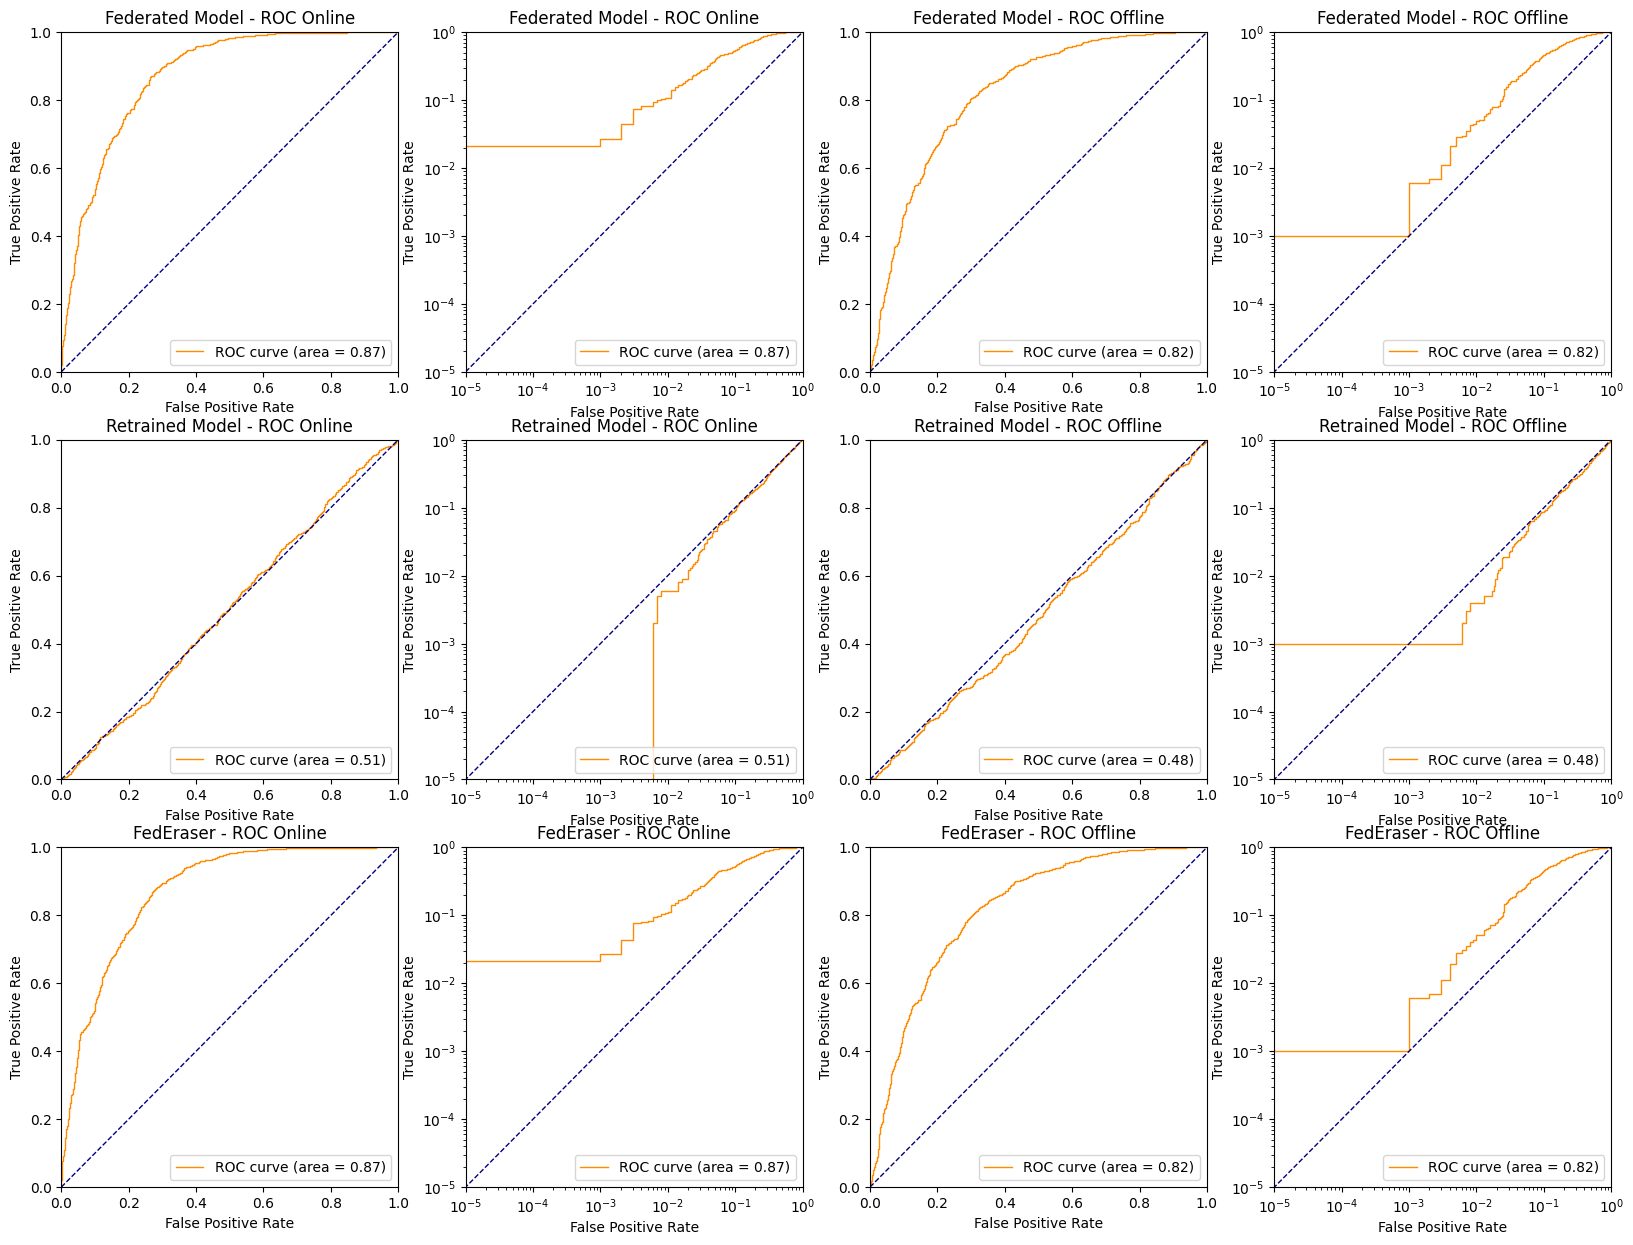

In [17]:
_, axes = plt.subplots(3, 4, figsize=(20, 15)) 
lira = StandardMIALira(N_SHADOW_MODELS, ds_att, target_model, target_model_memberships, create_model_fn, device=device, seed=SEED)
lira.load_shadow_models(SHADOW_FOLDER)

evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unl_global_model, axes)

# Stats Based LIRA

In [18]:
def features_extractor(model, x):
    features = get_activations(model, x)["avgpool"][:, :, 0, 0]
    #features = torch.flatten(nn.AdaptiveAvgPool2d((1,1))(activations["features"]), 1)
    return features

## Last Layer Max

Loaded 32 shadow models


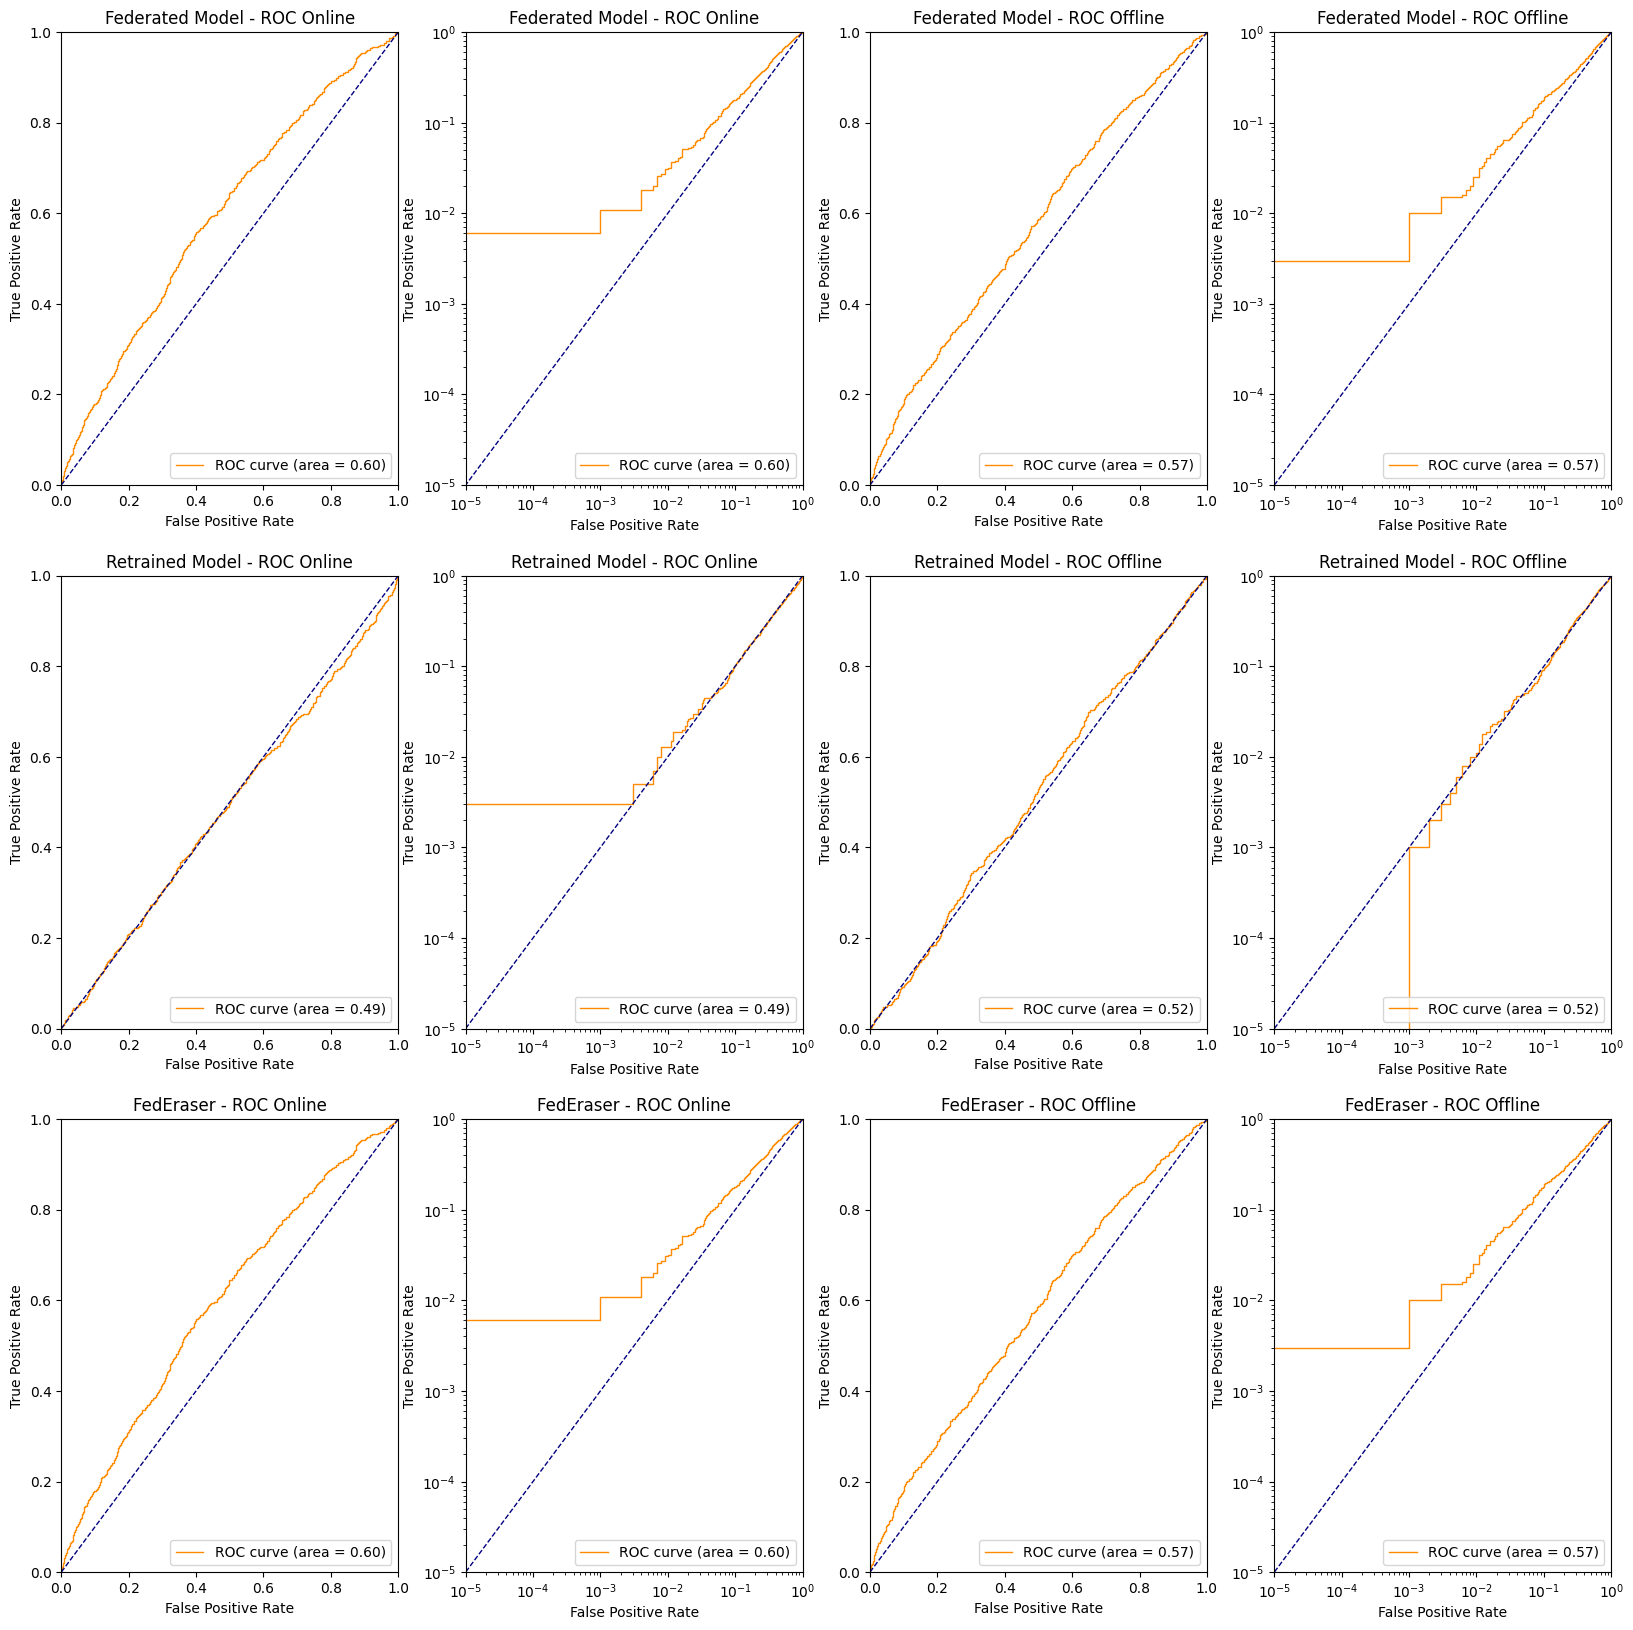

In [19]:
_, axes = plt.subplots(3, 4, figsize=(20, 20)) 
lira = MaxFeatureMIALira(N_SHADOW_MODELS, ds_att, global_model, target_model_memberships, create_model_fn, features_extractor, 
                         device=device, seed=SEED)
lira.load_shadow_models(SHADOW_FOLDER)

evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unl_global_model, axes)

## Last Layer Mean

Loaded 32 shadow models


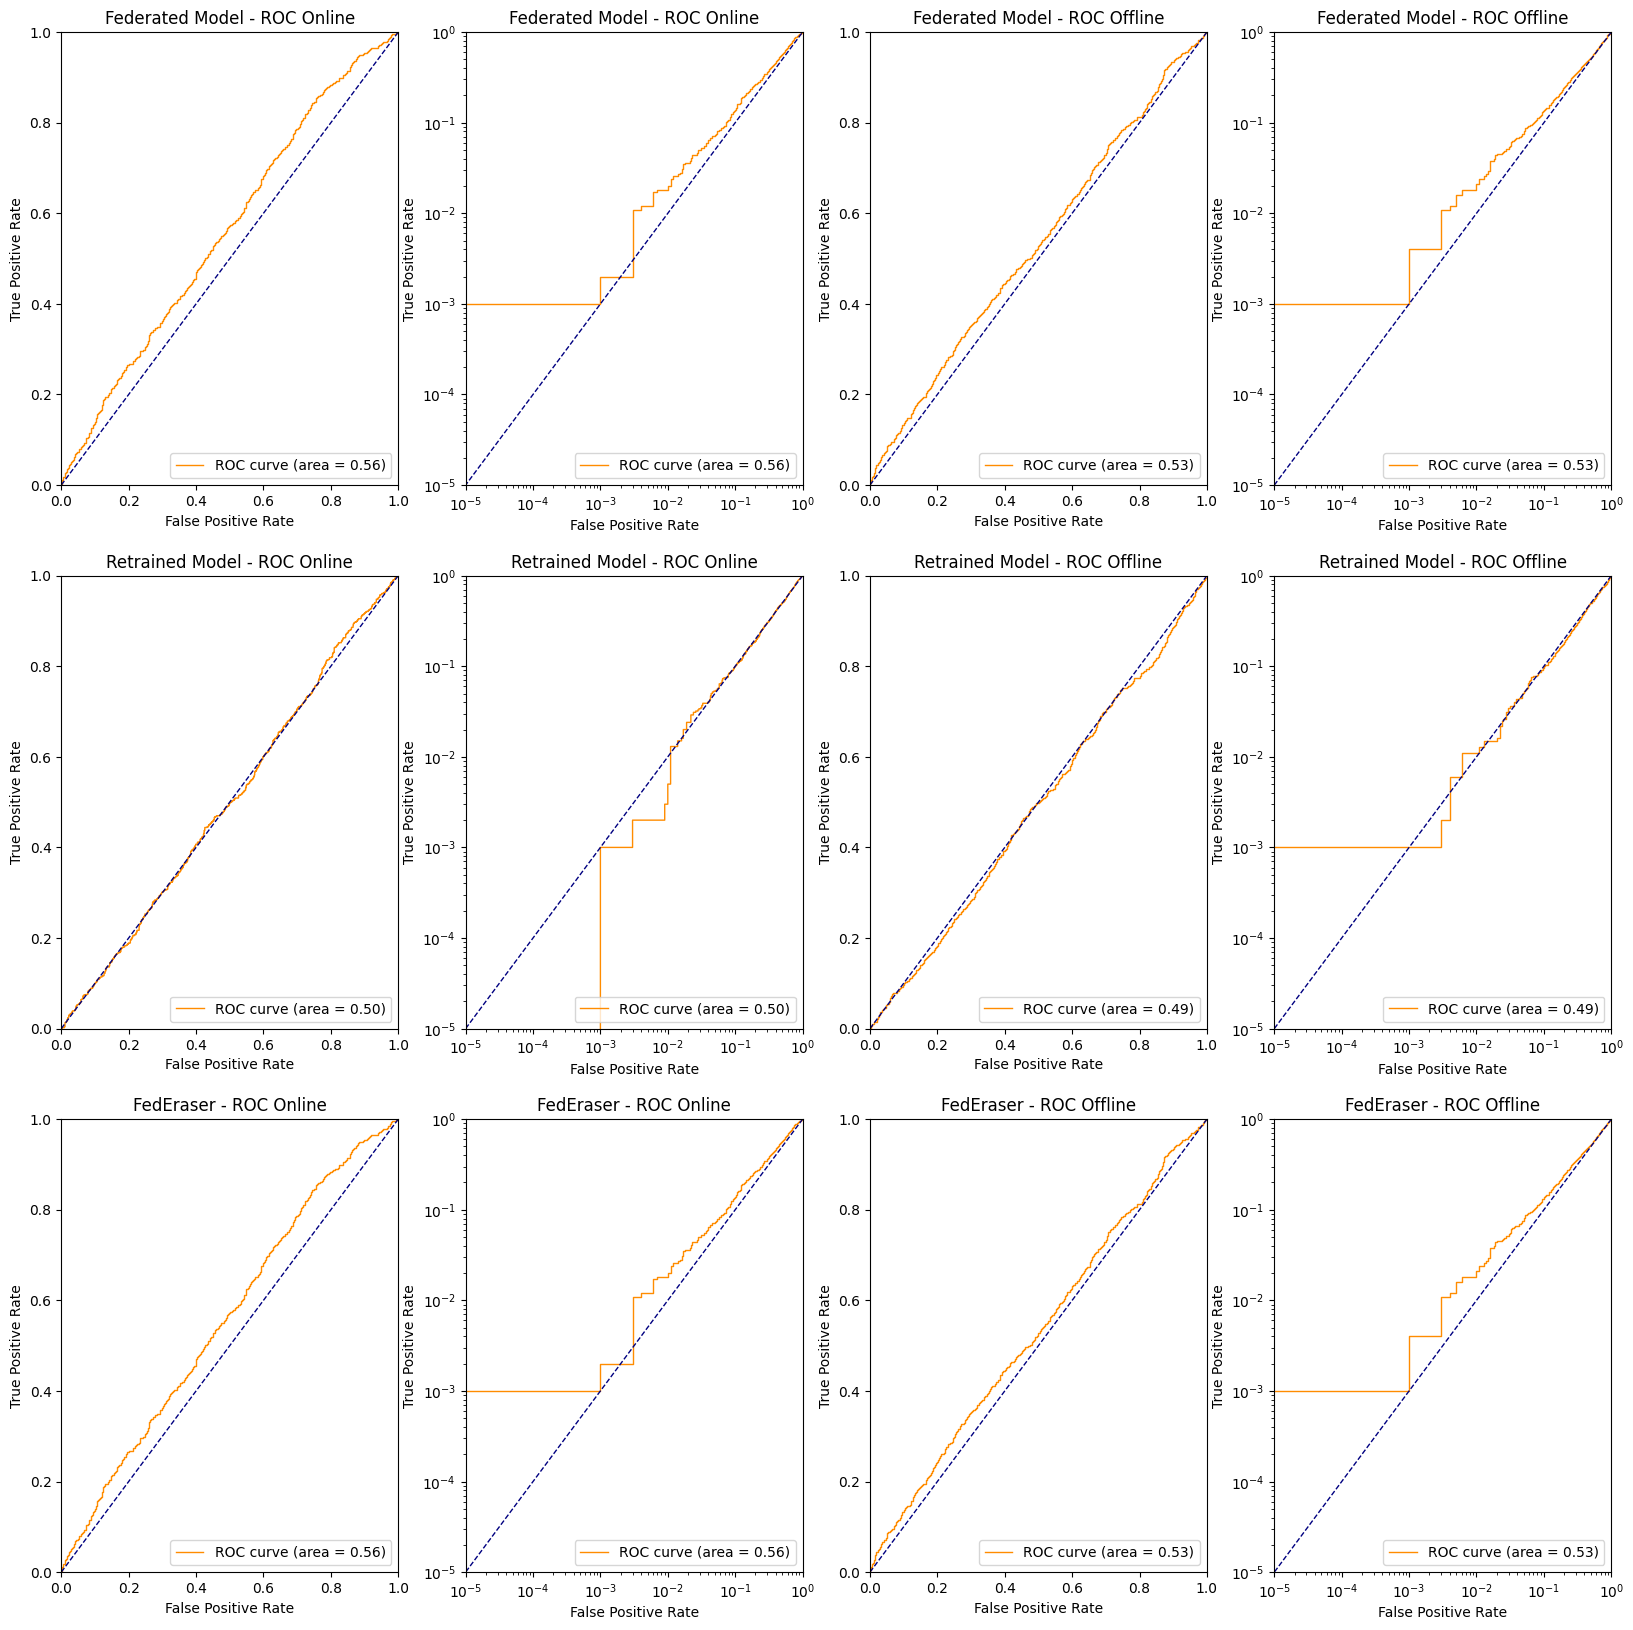

In [20]:
_, axes = plt.subplots(3, 4, figsize=(20, 20)) 
lira = MeanFeatureMIALira(N_SHADOW_MODELS, ds_att, global_model, target_model_memberships, create_model_fn, features_extractor, 
                         device=device, seed=SEED)
lira.load_shadow_models(SHADOW_FOLDER)

evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unl_global_model, axes)

## Last Layer Var

Loaded 32 shadow models


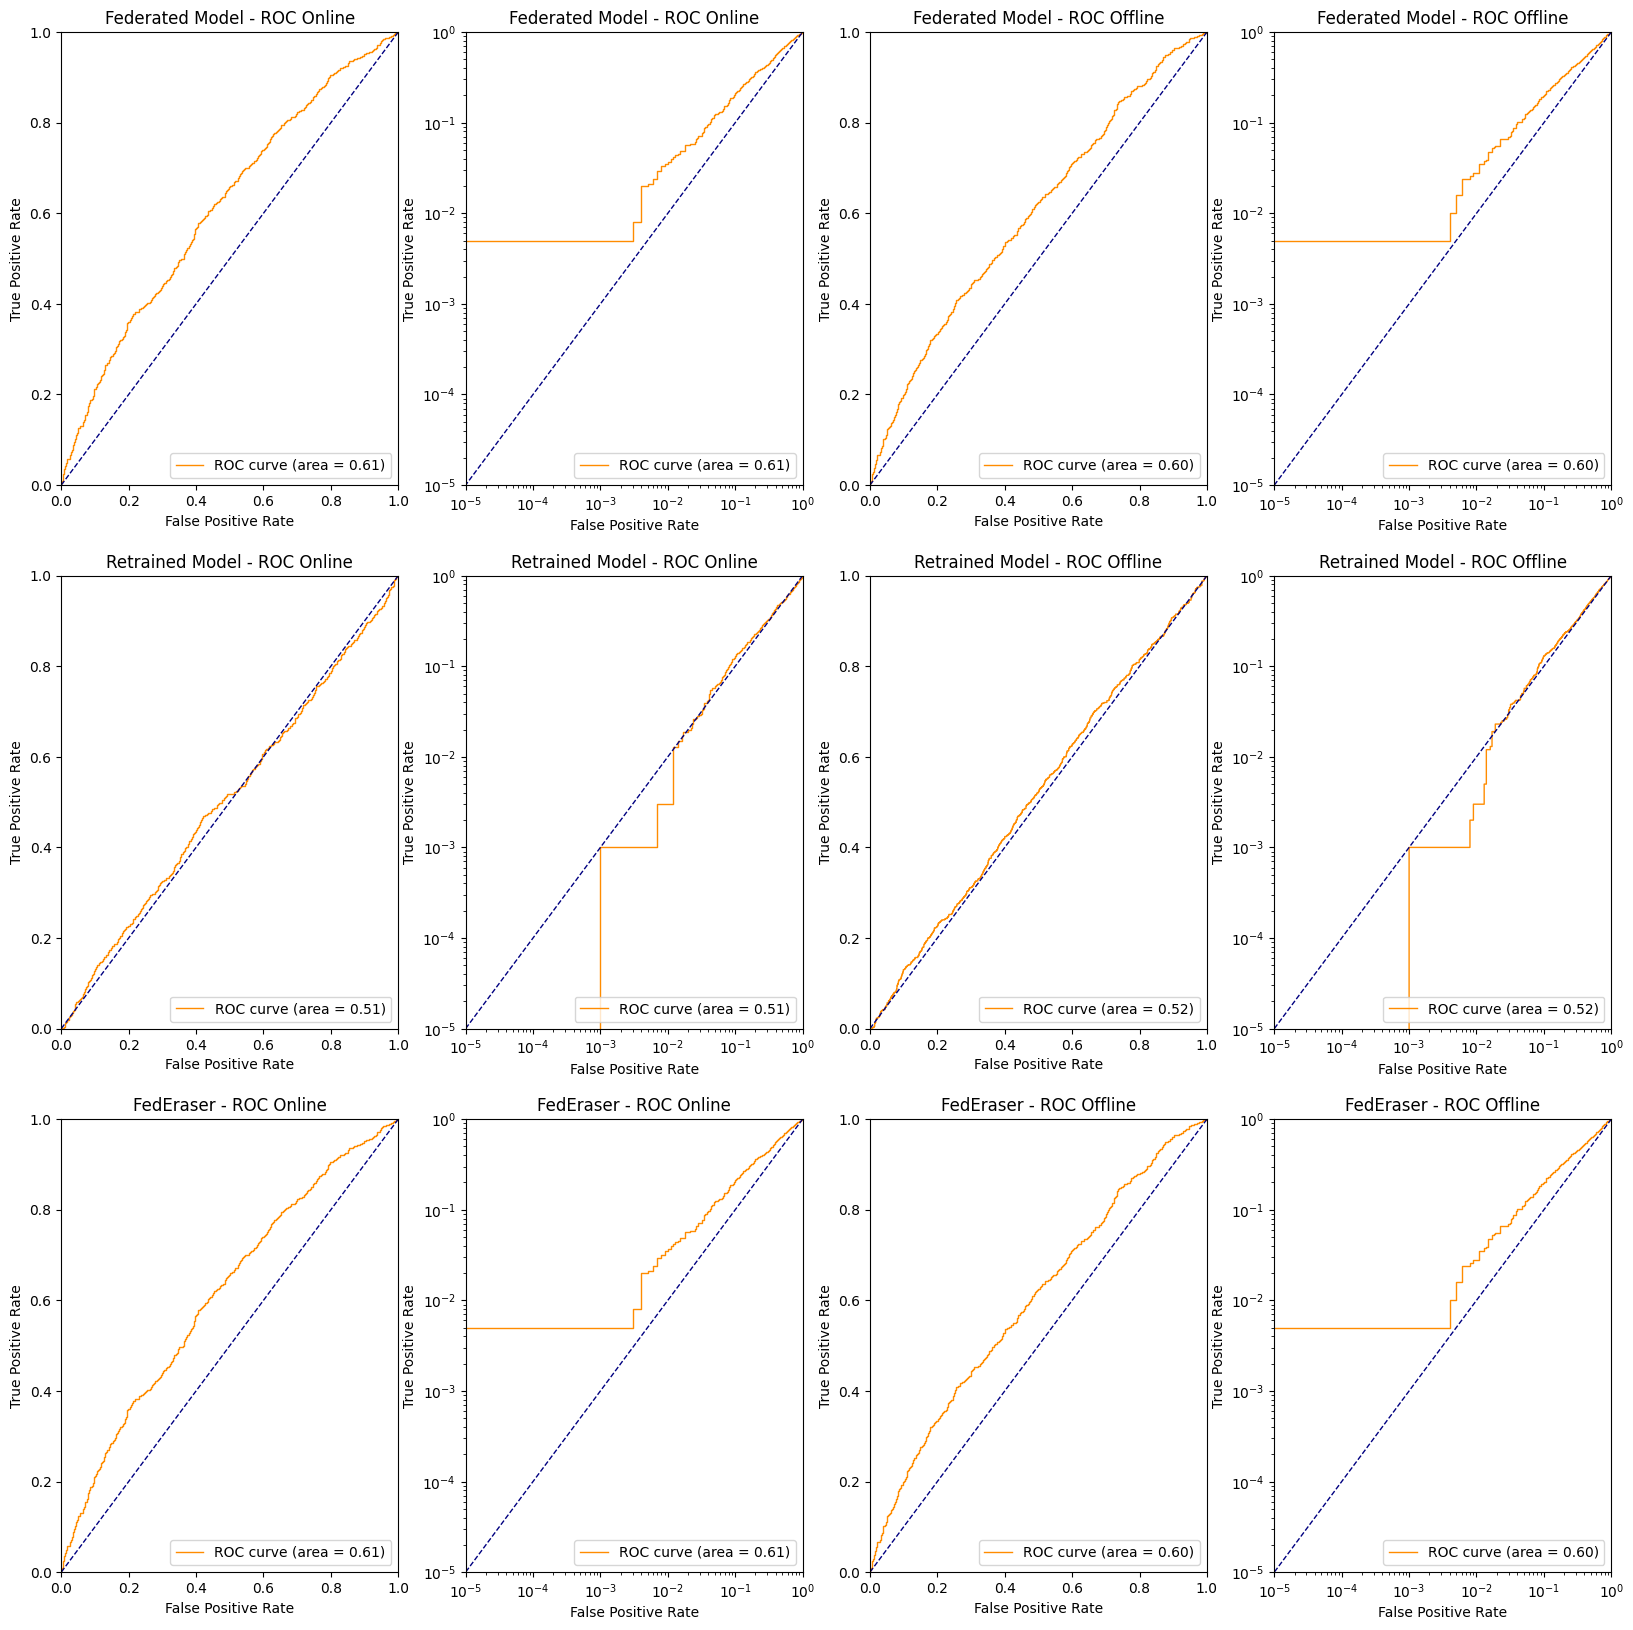

In [21]:
_, axes = plt.subplots(3, 4, figsize=(20, 20)) 
lira = VarFeatureMIALira(N_SHADOW_MODELS, ds_att, global_model, target_model_memberships, create_model_fn, features_extractor, 
                         device=device, seed=SEED)
lira.load_shadow_models(SHADOW_FOLDER)

evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unl_global_model, axes)

# Last Layer Norm

Loaded 32 shadow models


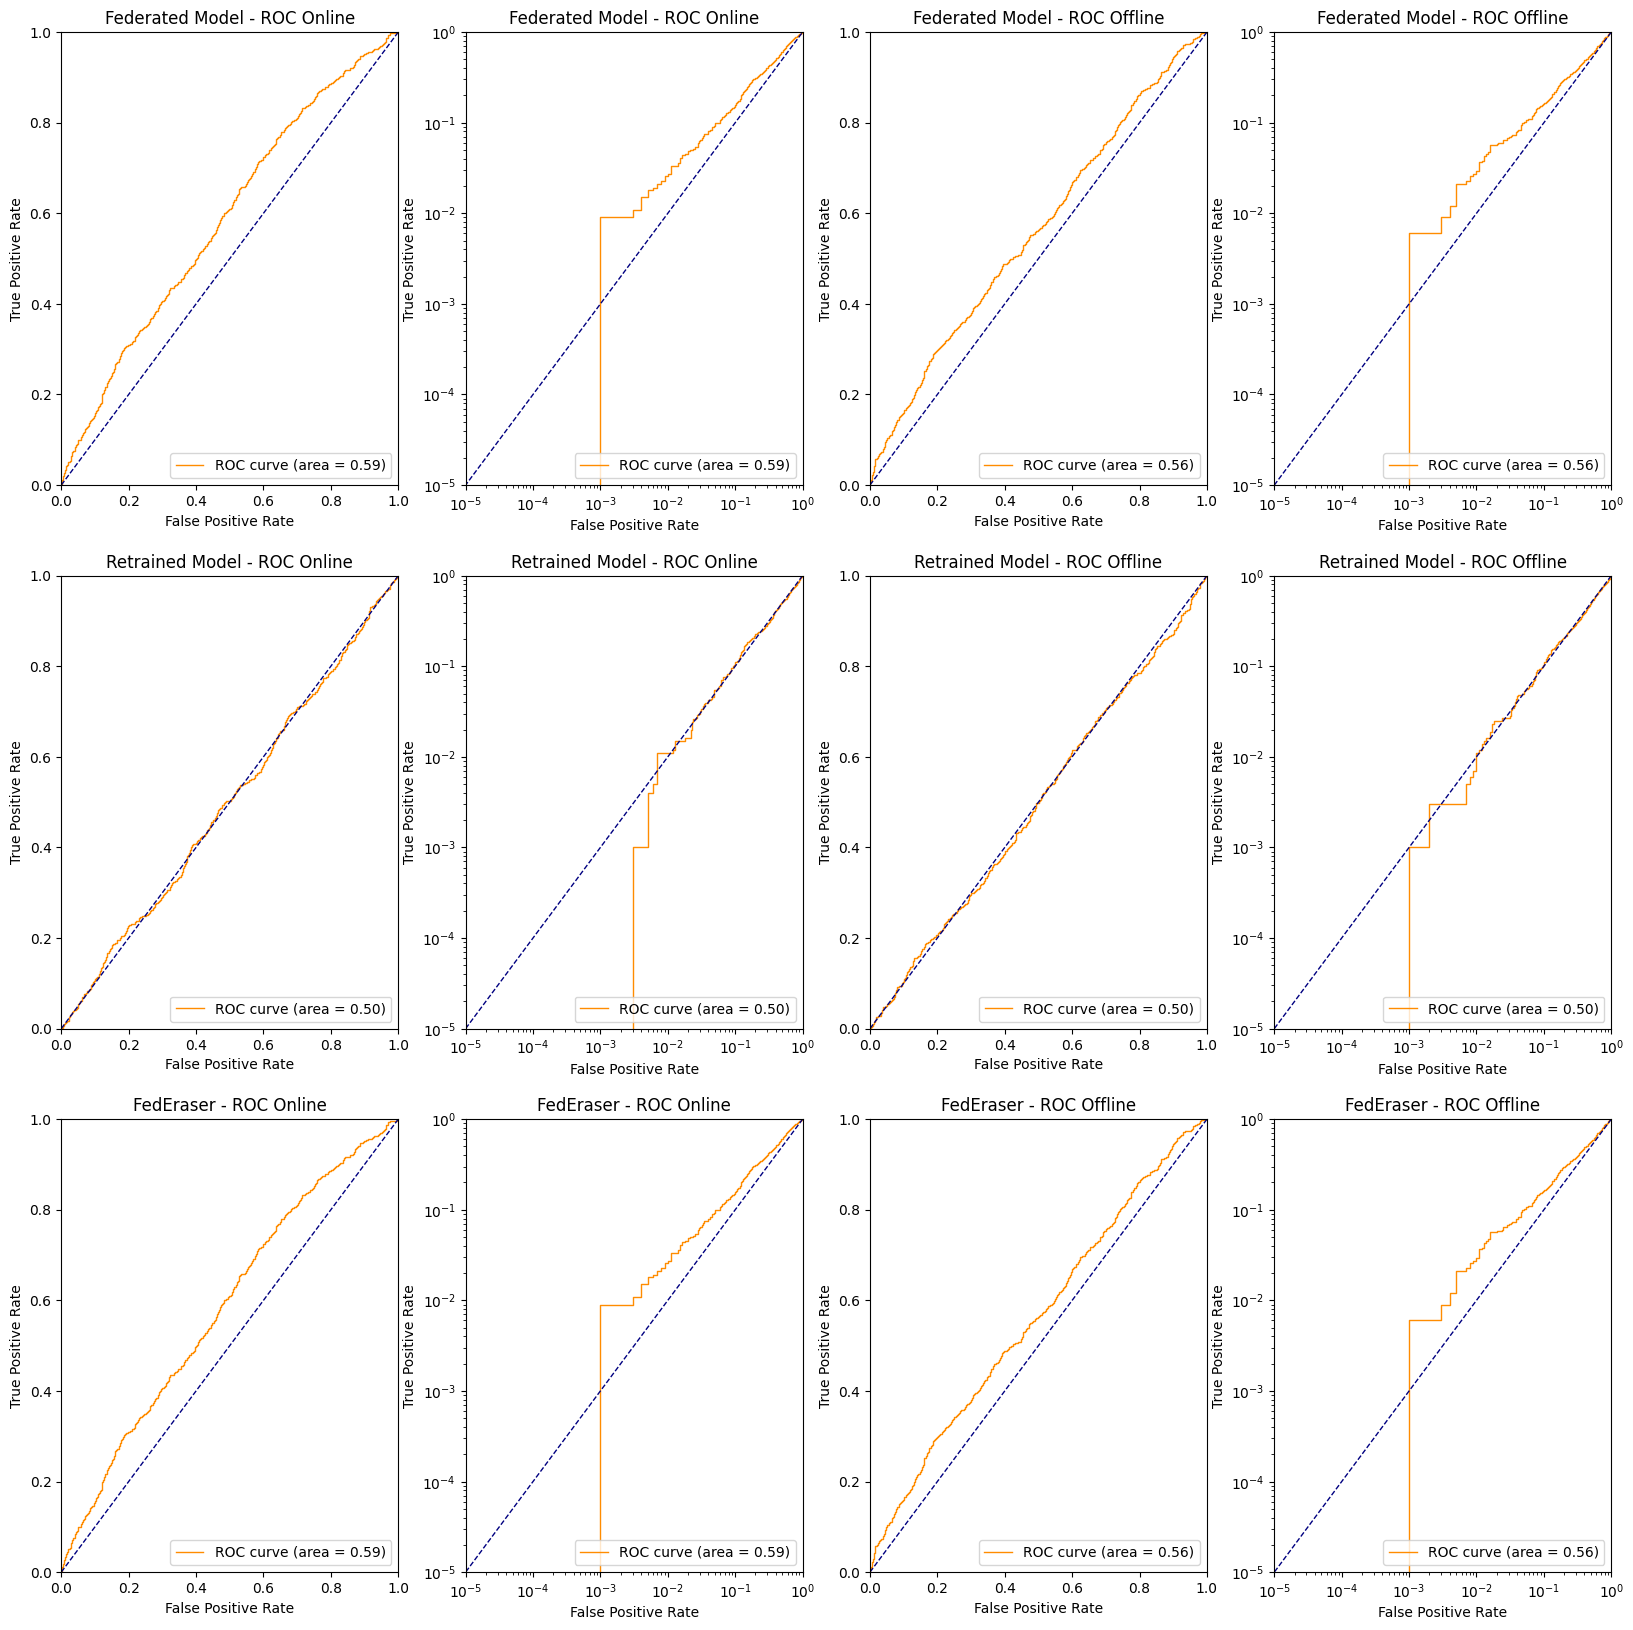

In [22]:
_, axes = plt.subplots(3, 4, figsize=(20, 20)) 
lira = NormFeatureMIALira(N_SHADOW_MODELS, ds_att, global_model, target_model_memberships, create_model_fn, features_extractor, 
                         device=device, seed=SEED)
lira.load_shadow_models(SHADOW_FOLDER)

evaluate_lira(lira, target_model_memberships, global_model, retrained_model, unl_global_model, axes)